In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv("/content/household_energy_consumption - household_energy_consumption.csv")
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [19]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [20]:
df.shape

(90000, 7)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [22]:
df.isnull().sum()

,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


In [23]:
df.dropna()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2
...,...,...,...,...,...,...,...
89995,H12857,2025-04-04,5.0,2,19.3,No,1.5
89996,H12857,2025-04-05,5.3,2,16.1,No,1.7
89997,H12857,2025-04-06,4.3,2,14.6,No,1.5
89998,H12857,2025-04-07,7.2,2,18.2,No,2.6


In [24]:
X=df[["Household_Size","Avg_Temperature_C","Peak_Hours_Usage_kWh"]]
y=df["Energy_Consumption_kWh"]

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [26]:
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [30]:
model=LinearRegression()
model.fit(X_train_poly,y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test_poly)

In [32]:
result=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred
})
print("\nActual vs Predicated:")
print(result.head(10))


Actual vs Predicated:
   Actual  Predicted
0    13.7  14.754917
1     7.3   7.626474
2    13.0  12.348609
3     9.0   8.556138
4    17.0  16.907604
5     9.9  10.114867
6     9.6   9.357839
7    10.0  10.212516
8    19.8  18.763752
9    13.0  13.533113


In [33]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [34]:
print("\nModel Evaluation")
print("-----------------")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R-squared:",r2)


Model Evaluation
-----------------
MAE: 0.5592832525343422
MSE: 0.5132741174711
RMSE: 0.716431516246389
R-squared: 0.9831459903864083


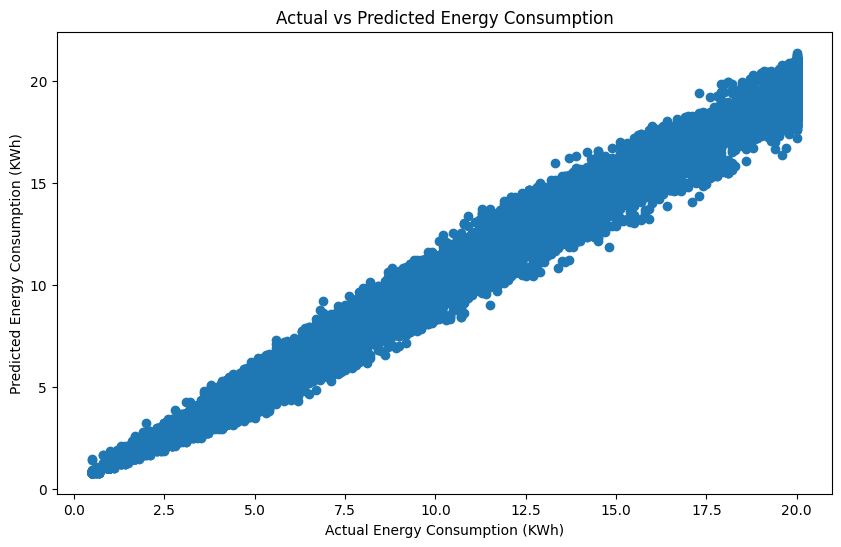

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption (KWh)")
plt.ylabel("Predicted Energy Consumption (KWh)")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()